# Exploration et nettoyage des données

Imports et connexion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"]      = 12

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

df_brut    = pd.read_sql("SELECT * FROM deputes", engine)
df_groupes = pd.read_sql("SELECT * FROM groupes_politiques", engine)
df_scrutins = pd.read_sql("SELECT * FROM scrutins", engine)

print(f"✅ Connexion établie")
print(f"\n── CHARGEMENT BRUT ─────────────────────────────────")
print(f"   Députés en base (brut)  : {len(df_brut):,}")
print(f"   Scrutins                : {len(df_scrutins):,}")
print(f"   Groupes politiques      : {len(df_groupes)}")
print(f"\n── APERÇU TABLE BRUTE ──────────────────────────────")
print(df_brut.dtypes)

✅ Connexion établie

── CHARGEMENT BRUT ─────────────────────────────────
   Députés en base (brut)  : 577
   Scrutins                : 6,899
   Groupes politiques      : 12

── APERÇU TABLE BRUTE ──────────────────────────────
id                                int64
uid                              object
nom                              object
prenom                           object
nom_complet                      object
civilite                         object
date_naissance                   object
age                               int64
lieu_naissance                   object
departement_naissance            object
profession                       object
groupe_sigle                     object
groupe_nom                       object
url_photo                        object
collecte_le              datetime64[ns]
dtype: object


Audit qualité

In [2]:
print("── AUDIT QUALITÉ   TABLE DÉPUTÉS (BRUT) ───────────")
print(f"\n{'Colonne':<30} {'Type':<15} {'Renseignées':>11} "
      f"{'Manquantes':>11} {'% complet':>10} {'Unique':>8}")
print("-" * 88)

audit_rows = []
for col in df_brut.columns:
    total      = len(df_brut)
    manquantes = df_brut[col].isna().sum()
    renseignes = total - manquantes
    pct        = renseignes / total * 100
    nunique    = df_brut[col].nunique()
    dtype      = str(df_brut[col].dtype)
    flag       = " ⚠️" if pct < 80 else ""
    print(f"{col:<30} {dtype:<15} {renseignes:>11,} "
          f"{manquantes:>11,} {pct:>9.1f}%{flag:<3} {nunique:>8,}")
    audit_rows.append({
        "colonne": col, "type": dtype,
        "renseignees": renseignes, "manquantes": manquantes,
        "pct_complet": pct, "nunique": nunique
    })

df_audit = pd.DataFrame(audit_rows)
print(f"\n── RÉSUMÉ ──────────────────────────────────────────")
print(f"   Colonnes complètes (100%) : "
      f"{(df_audit['pct_complet']==100).sum()}")
print(f"   Colonnes avec manquants   : "
      f"{(df_audit['pct_complet']<100).sum()}")
print(f"   Taux de complétion global : "
      f"{df_audit['pct_complet'].mean():.1f}%")

── AUDIT QUALITÉ   TABLE DÉPUTÉS (BRUT) ───────────

Colonne                        Type            Renseignées  Manquantes  % complet   Unique
----------------------------------------------------------------------------------------
id                             int64                   577           0     100.0%         577
uid                            object                  577           0     100.0%         577
nom                            object                  577           0     100.0%         562
prenom                         object                  577           0     100.0%         304
nom_complet                    object                  577           0     100.0%         577
civilite                       object                  577           0     100.0%           2
date_naissance                 object                  577           0     100.0%         561
age                            int64                   577           0     100.0%          55
lieu_naissance 

Statistiques descriptives brutes

In [3]:
print("── STATISTIQUES DESCRIPTIVES   VARIABLES NUMÉRIQUES ─")
print(f"\n{'Métrique':<20} {'age':>10} {'pour':>10} "
      f"{'contre':>10} {'abstention':>12} {'participation':>15}")
print("-" * 80)

cols_num = ["age", "pour", "contre", "abstention", "taux_participation"]
df_num   = pd.concat([
    df_brut[["age"]],
    df_scrutins[["pour", "contre", "abstention", "taux_participation"]]
], axis=0)

metriques = {
    "Count":    lambda x: x.count(),
    "Mean":     lambda x: x.mean(),
    "Std":      lambda x: x.std(),
    "Min":      lambda x: x.min(),
    "Q25":      lambda x: x.quantile(0.25),
    "Median":   lambda x: x.median(),
    "Q75":      lambda x: x.quantile(0.75),
    "Max":      lambda x: x.max(),
    "Skewness": lambda x: x.skew(),
    "Kurtosis": lambda x: x.kurtosis(),
}

stats_df = pd.DataFrame({
    col: {name: func(df_brut[col].dropna())
          if col in df_brut.columns
          else func(df_scrutins[col].dropna())
          for name, func in metriques.items()}
    for col in cols_num
})
print(stats_df.round(2).to_string())

print(f"\n── INTERPRÉTATION ──────────────────────────────────")
age_skew = df_brut["age"].skew()
print(f"   Âge   skewness : {age_skew:.3f} "
      f"({'distribution asymétrique droite' if age_skew > 0 else 'distribution asymétrique gauche'})")
part_skew = df_scrutins["taux_participation"].skew()
print(f"   Participation   skewness : {part_skew:.3f} "
      f"({'distribution asymétrique droite' if part_skew > 0 else 'distribution asymétrique gauche'})")

── STATISTIQUES DESCRIPTIVES   VARIABLES NUMÉRIQUES ─

Métrique                    age       pour     contre   abstention   participation
--------------------------------------------------------------------------------
             age     pour   contre  abstention  taux_participation
Count     577.00  6899.00  6899.00     6899.00             6899.00
Mean       51.45    69.19    76.01        9.10               26.74
Std        12.02    52.80    54.17       17.92               13.90
Min        25.00     0.00     0.00        0.00                2.80
Q25        41.00    35.00    34.00        1.00               16.50
Median     53.00    57.00    70.00        3.00               24.60
Q75        60.00    87.00   110.00        8.00               34.80
Max        83.00   560.00   404.00      257.00               99.50
Skewness   -0.04     2.57     0.77        3.78                1.19
Kurtosis   -0.78    11.85     0.77       20.00                2.84

── INTERPRÉTATION ─────────────────────────

Détection des outliers

In [4]:
print("── DÉTECTION DES OUTLIERS   MÉTHODE IQR ───────────")

def detecter_outliers_iqr(serie, nom):
    serie   = serie.dropna()
    Q1      = serie.quantile(0.25)
    Q3      = serie.quantile(0.75)
    IQR     = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers  = serie[(serie < borne_inf) | (serie > borne_sup)]
    print(f"\n   {nom}")
    print(f"   Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR:.1f}")
    print(f"   Bornes : [{borne_inf:.1f}, {borne_sup:.1f}]")
    print(f"   Outliers détectés : {len(outliers)} "
          f"({len(outliers)/len(serie)*100:.1f}%)")
    if len(outliers) > 0 and len(outliers) <= 10:
        print(f"   Valeurs : {sorted(outliers.tolist())}")
    return outliers

outliers_age  = detecter_outliers_iqr(df_brut["age"], "Âge des députés")
outliers_pour = detecter_outliers_iqr(df_scrutins["pour"], "Votes Pour")
outliers_part = detecter_outliers_iqr(
    df_scrutins["taux_participation"], "Taux de participation"
)

print(f"\n── DÉCISION ────────────────────────────────────────")
print(f"   Âge : outliers conservés   valeurs réelles vérifiables")
print(f"   Votes : outliers conservés   scrutins légitimes")
print(f"   Participation : outliers conservés   mobilisations réelles")

── DÉTECTION DES OUTLIERS   MÉTHODE IQR ───────────

   Âge des députés
   Q1=41.0 | Q3=60.0 | IQR=19.0
   Bornes : [12.5, 88.5]
   Outliers détectés : 0 (0.0%)

   Votes Pour
   Q1=35.0 | Q3=87.0 | IQR=52.0
   Bornes : [-43.0, 165.0]
   Outliers détectés : 367 (5.3%)

   Taux de participation
   Q1=16.5 | Q3=34.8 | IQR=18.3
   Bornes : [-10.9, 62.2]
   Outliers détectés : 114 (1.7%)

── DÉCISION ────────────────────────────────────────
   Âge : outliers conservés   valeurs réelles vérifiables
   Votes : outliers conservés   scrutins légitimes
   Participation : outliers conservés   mobilisations réelles


Nettoyage documenté

In [5]:
print("── NETTOYAGE ÉTAPE PAR ÉTAPE ───────────────────────")

df = df_brut.copy()
rapport_nettoyage = []

# Étape 1 : Filtre groupe politique
avant = len(df)
df    = df[df["groupe_sigle"].notna()].copy()
apres = len(df)
rapport_nettoyage.append({
    "etape": "Filtre groupe politique",
    "avant": avant, "apres": apres,
    "retires": avant - apres,
    "raison": "Acteurs sans mandat actif en 17e législature"
})
print(f"\n   Étape 1   Filtre groupe politique")
print(f"   {avant:,} → {apres:,} | Retirés : {avant-apres:,}")

# Étape 2 : Nettoyage valeurs XML
def nettoyer_valeur(val):
    """Nettoie les artéfacts XML de l'API (@xsi:nil, @xmlns:xsi)."""
    if isinstance(val, dict):
        if "@xsi:nil" in val or "@xmlns:xsi" in val:
            return None
        for k in ("#text", "value", "text"):
            if k in val:
                return str(val[k])
        return None
    if isinstance(val, str) and val.startswith("{'@"):
        return None
    return val

avant_prof = df["profession"].notna().sum()
df["profession"] = df["profession"].apply(nettoyer_valeur)
apres_prof = df["profession"].notna().sum()
rapport_nettoyage.append({
    "etape": "Nettoyage XML professions",
    "avant": avant_prof, "apres": apres_prof,
    "retires": avant_prof - apres_prof,
    "raison": "Valeurs @xsi:nil retournées par l'API"
})
print(f"\n   Étape 2   Nettoyage valeurs XML (@xsi:nil)")
print(f"   Professions : {avant_prof:,} → {apres_prof:,}")

# Étape 3 : Conversion dates
avant_dates = df["date_naissance"].notna().sum()
df["date_naissance"] = pd.to_datetime(df["date_naissance"], errors="coerce")
apres_dates = df["date_naissance"].notna().sum()
rapport_nettoyage.append({
    "etape": "Conversion date_naissance",
    "avant": avant_dates, "apres": apres_dates,
    "retires": avant_dates - apres_dates,
    "raison": "Formats non parsables convertis en NaT"
})
print(f"\n   Étape 3   Conversion dates")
print(f"   Dates valides : {apres_dates:,} / {len(df):,}")

# Étape 4 : Calcul âge
df["age_calcule"] = df["date_naissance"].apply(
    lambda d: int((pd.Timestamp.now() - d).days / 365.25)
    if pd.notna(d) else None
)
coherence_age = (
    (df["age"] - df["age_calcule"]).abs() <= 1
).sum()
print(f"\n   Étape 4   Validation âge")
print(f"   Cohérence age DB vs age calculé (±1 an) : "
      f"{coherence_age:,} / {df['age'].notna().sum():,}")

# Étape 5 : Genre
df["genre"] = df["civilite"].map({"M.": "Homme", "Mme": "Femme"})
print(f"\n   Étape 5   Déduction genre")
print(f"   Hommes : {(df['genre']=='Homme').sum():,} | "
      f"Femmes : {(df['genre']=='Femme').sum():,} | "
      f"Non mappés : {df['genre'].isna().sum()}")

# Rapport final
df_rapport = pd.DataFrame(rapport_nettoyage)
print(f"\n── RAPPORT DE NETTOYAGE ────────────────────────────")
print(df_rapport.to_string(index=False))
print(f"\n   Dataset final : {len(df):,} députés actifs")
print(f"   Taux de complétion global : "
      f"{df.notna().mean().mean()*100:.1f}%")

── NETTOYAGE ÉTAPE PAR ÉTAPE ───────────────────────

   Étape 1   Filtre groupe politique
   577 → 577 | Retirés : 0

   Étape 2   Nettoyage valeurs XML (@xsi:nil)
   Professions : 577 → 577

   Étape 3   Conversion dates
   Dates valides : 577 / 577

   Étape 4   Validation âge
   Cohérence age DB vs age calculé (±1 an) : 577 / 577

   Étape 5   Déduction genre
   Hommes : 358 | Femmes : 219 | Non mappés : 0

── RAPPORT DE NETTOYAGE ────────────────────────────
                    etape  avant  apres  retires                                       raison
  Filtre groupe politique    577    577        0 Acteurs sans mandat actif en 17e législature
Nettoyage XML professions    577    577        0        Valeurs @xsi:nil retournées par l'API
Conversion date_naissance    577    577        0       Formats non parsables convertis en NaT

   Dataset final : 577 députés actifs
   Taux de complétion global : 99.7%


Export données nettoyées

In [6]:
os.makedirs("../data/processed", exist_ok=True)

# Export députés nettoyés
df.to_csv("../data/processed/deputes_clean.csv", index=False, encoding="utf-8")
print(f"✅ deputes_clean.csv exporté ({len(df):,} lignes)")

# Export KPIs summary
kpis = {
    "nb_deputes":           len(df),
    "nb_scrutins":          len(df_scrutins),
    "nb_groupes":           len(df_groupes),
    "pct_femmes":           round((df["genre"]=="Femme").mean()*100, 2),
    "age_moyen":            round(df["age"].mean(), 1),
    "age_median":           round(df["age"].median(), 1),
    "age_min":              int(df["age"].min()),
    "age_max":              int(df["age"].max()),
    "pct_adoptes":          round(df_scrutins["adopte"].mean()*100, 2),
    "participation_moy":    round(df_scrutins["taux_participation"].mean(), 2),
    "nb_professions_uniq":  int(df["profession"].nunique()),
}
pd.DataFrame([kpis]).to_csv(
    "../data/processed/kpis_summary.csv", index=False
)
print(f"✅ kpis_summary.csv exporté")
print(f"\n── KPIs PRINCIPAUX ─────────────────────────────────")
for k, v in kpis.items():
    print(f"   {k:<25} : {v}")

✅ deputes_clean.csv exporté (577 lignes)
✅ kpis_summary.csv exporté

── KPIs PRINCIPAUX ─────────────────────────────────
   nb_deputes                : 577
   nb_scrutins               : 6899
   nb_groupes                : 12
   pct_femmes                : 37.95
   age_moyen                 : 51.4
   age_median                : 53.0
   age_min                   : 25
   age_max                   : 83
   pct_adoptes               : 35.28
   participation_moy         : 26.74
   nb_professions_uniq       : 274


Visualisation qualité avant/après

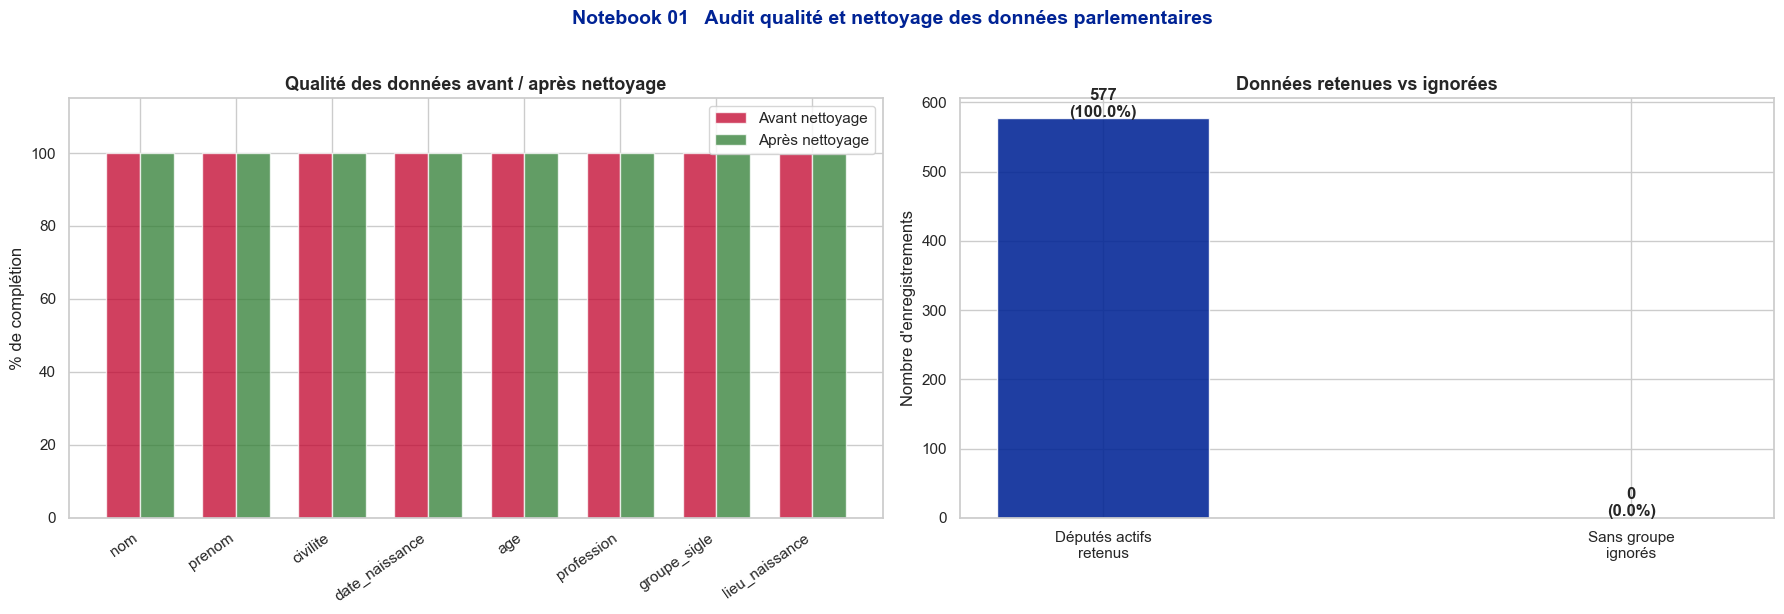

✅ Figure 1 sauvegardée


In [7]:
COULEURS_GROUPES = {
    "RN":      "#1E3A8A", "EPR":     "#DAA520",
    "LFI-NFP": "#CC0000", "SOC":     "#E91E63",
    "DR":      "#1565C0", "ECO":     "#2E7D32",
    "DEM":     "#FF8F00", "HOR":     "#00838F",
    "LIOT":    "#6A1B9A", "GDR":     "#B71C1C",
    "UDR":     "#0D47A1", "NI":      "#757575",
}

cols_analyse = ["nom", "prenom", "civilite", "date_naissance",
                "age", "profession", "groupe_sigle", "lieu_naissance"]
completude = pd.DataFrame({
    "colonne": cols_analyse,
    "avant":   [df_brut[c].notna().mean() * 100 for c in cols_analyse],
    "apres":   [df[c].notna().mean() * 100 for c in cols_analyse],
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x     = range(len(completude))
width = 0.35
axes[0].bar([i - width/2 for i in x], completude["avant"],
            width, label="Avant nettoyage",
            color="#C1002A", alpha=0.75, edgecolor="white")
axes[0].bar([i + width/2 for i in x], completude["apres"],
            width, label="Après nettoyage",
            color="#2E7D32", alpha=0.75, edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(completude["colonne"], rotation=35, ha="right")
axes[0].set_ylabel("% de complétion")
axes[0].set_ylim(0, 115)
axes[0].set_title("Qualité des données avant / après nettoyage",
                   fontsize=13, fontweight="bold")
axes[0].legend()
for i, row in completude.iterrows():
    if row["apres"] != row["avant"]:
        axes[0].annotate(
            f"−{row['avant']-row['apres']:.1f}%",
            xy=(i + width/2, row["apres"] + 2),
            ha="center", fontsize=8, color="#C1002A"
        )

categories = ["Députés actifs\nretenus", "Sans groupe\nignorés"]
valeurs    = [len(df), len(df_brut) - len(df)]
couleurs   = ["#002395", "#bdc3d1"]
bars = axes[1].bar(categories, valeurs,
                   color=couleurs, edgecolor="white",
                   alpha=0.88, width=0.4)
for bar, v in zip(bars, valeurs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{v:,}\n({v/len(df_brut)*100:.1f}%)",
        ha="center", fontweight="bold", fontsize=12
    )
axes[1].set_ylabel("Nombre d'enregistrements")
axes[1].set_title("Données retenues vs ignorées",
                   fontsize=13, fontweight="bold")

plt.suptitle(
    "Notebook 01   Audit qualité et nettoyage des données parlementaires",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/01_qualite_nettoyage.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 sauvegardée")

Fragmentation de l'hémicycle

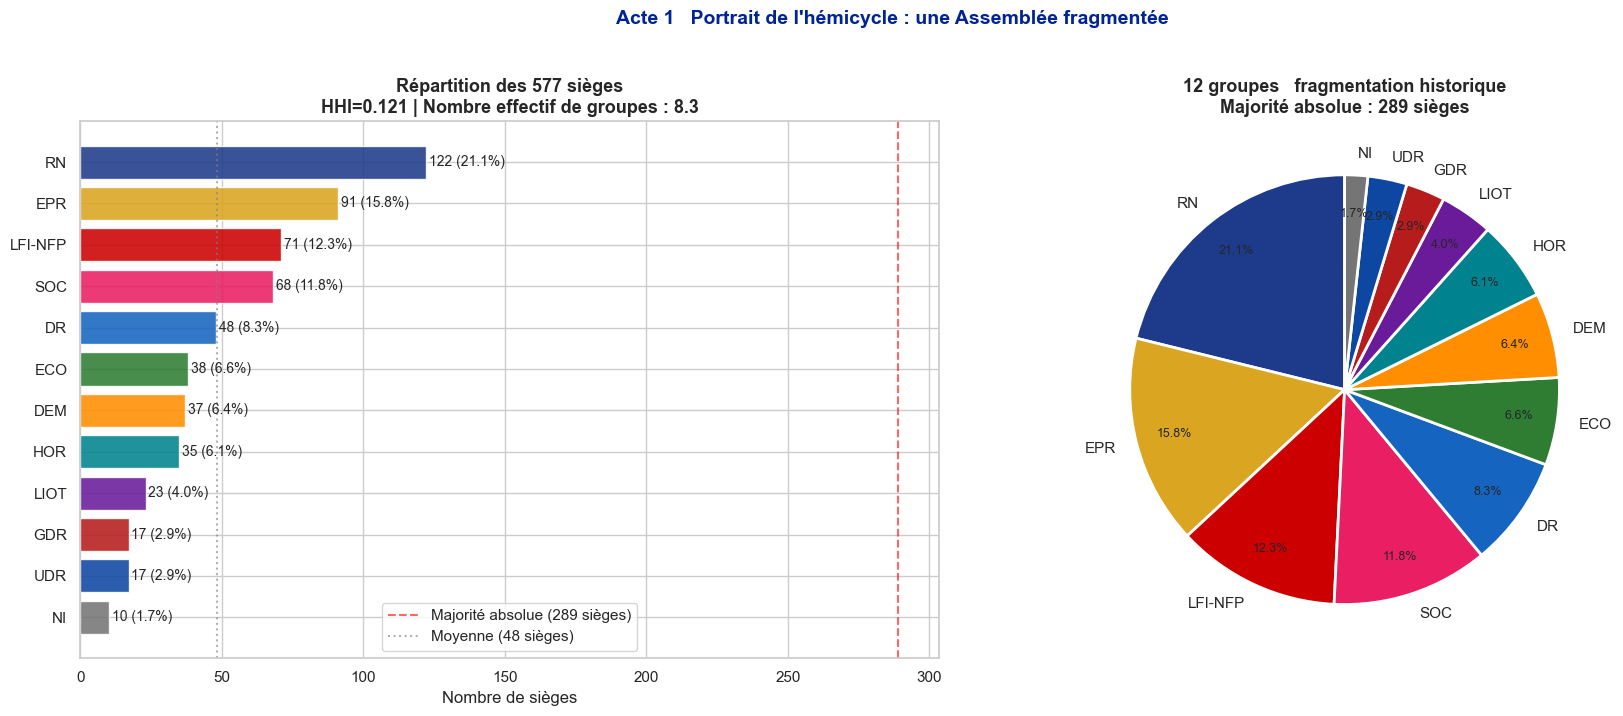

✅ Figure 2 sauvegardée

   Indice HHI : 0.121 (proche de 0 = très fragmenté)
   Nombre effectif de groupes : 8.3
   Groupe dominant : RN (21.1% des sièges)


In [8]:
groupes_count = (
    df.groupby("groupe_sigle")
    .size()
    .reset_index(name="nb")
    .sort_values("nb", ascending=False)
)
groupes_count = groupes_count.merge(
    df_groupes[["sigle", "nom"]],
    left_on="groupe_sigle", right_on="sigle", how="left"
)
groupes_count["pct"]     = (
    groupes_count["nb"] / groupes_count["nb"].sum() * 100
).round(1)
groupes_count["couleur"] = groupes_count["groupe_sigle"].map(COULEURS_GROUPES)

# Indice de fragmentation de Herfindahl-Hirschman (HHI)
# Plus il est bas, plus l'hémicycle est fragmenté
pcts  = groupes_count["pct"].values / 100
HHI   = (pcts ** 2).sum()
N_eff = 1 / HHI  # Nombre effectif de partis

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bars = axes[0].barh(
    groupes_count["groupe_sigle"],
    groupes_count["nb"],
    color=groupes_count["couleur"],
    edgecolor="white", alpha=0.88
)
axes[0].axvline(289, color="red", linestyle="--", alpha=0.6,
                label="Majorité absolue (289 sièges)")
axes[0].axvline(groupes_count["nb"].mean(), color="gray",
                linestyle=":", alpha=0.6,
                label=f"Moyenne ({groupes_count['nb'].mean():.0f} sièges)")
for bar, nb, pct in zip(bars, groupes_count["nb"], groupes_count["pct"]):
    axes[0].text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{nb} ({pct}%)", va="center", fontsize=10
    )
axes[0].set_xlabel("Nombre de sièges")
axes[0].set_title(
    f"Répartition des 577 sièges\n"
    f"HHI={HHI:.3f} | Nombre effectif de groupes : {N_eff:.1f}",
    fontsize=13, fontweight="bold"
)
axes[0].legend()
axes[0].invert_yaxis()

wedges, texts, autotexts = axes[1].pie(
    groupes_count["nb"],
    labels=groupes_count["groupe_sigle"],
    colors=groupes_count["couleur"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(linewidth=2, edgecolor="white")
)
for text in autotexts:
    text.set_fontsize(9)
axes[1].set_title(
    f"12 groupes   fragmentation historique\n"
    f"Majorité absolue : 289 sièges",
    fontsize=13, fontweight="bold"
)

plt.suptitle(
    "Acte 1   Portrait de l'hémicycle : une Assemblée fragmentée",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/02_fragmentation_hemicycle.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2 sauvegardée")
print(f"\n   Indice HHI : {HHI:.3f} (proche de 0 = très fragmenté)")
print(f"   Nombre effectif de groupes : {N_eff:.1f}")
print(f"   Groupe dominant : {groupes_count.iloc[0]['groupe_sigle']} "
      f"({groupes_count.iloc[0]['pct']}% des sièges)")

Portrait démographique avec stats 

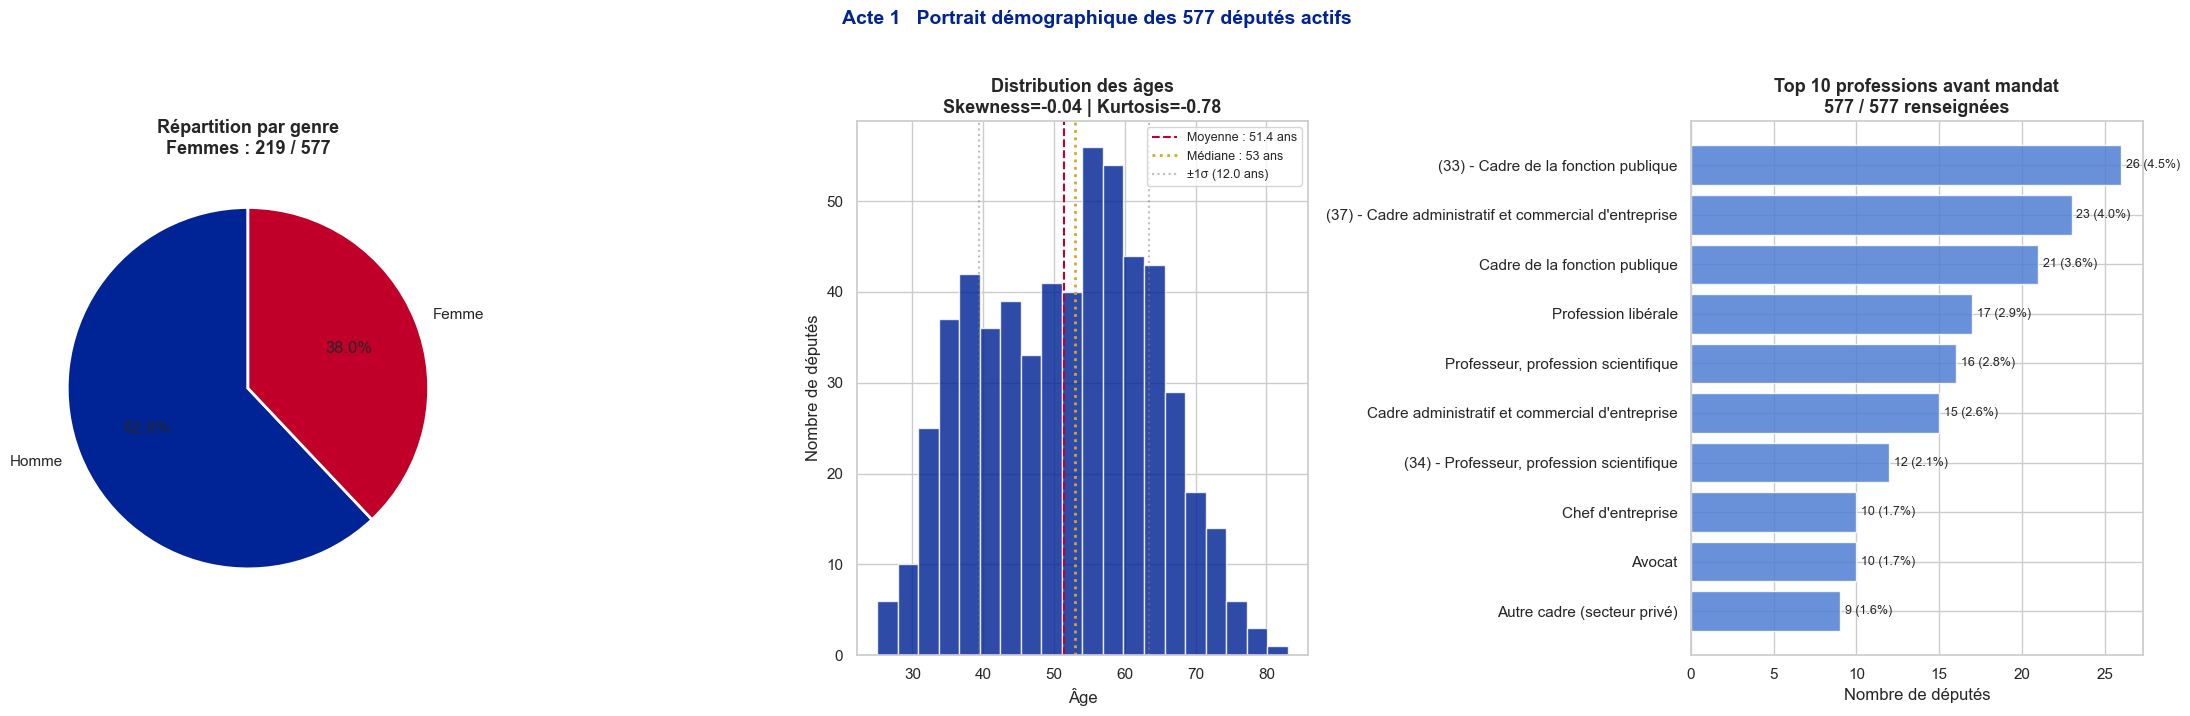

✅ Figure 3 sauvegardée


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

genre_counts = df["genre"].value_counts()
axes[0].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    colors=["#002395", "#C1002A"],
    startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor="white")
)
axes[0].set_title(
    f"Répartition par genre\n"
    f"Femmes : {(df['genre']=='Femme').sum()} / {len(df)}",
    fontsize=13, fontweight="bold"
)

ages = df["age"].dropna()
axes[1].hist(ages, bins=20, color="#002395",
             edgecolor="white", alpha=0.82, density=False)
axes[1].axvline(ages.mean(), color="#C1002A", linestyle="--",
                label=f"Moyenne : {ages.mean():.1f} ans")
axes[1].axvline(ages.median(), color="#DAA520", linestyle=":",
                linewidth=2, label=f"Médiane : {ages.median():.0f} ans")
axes[1].axvline(ages.mean() - ages.std(), color="gray",
                linestyle=":", alpha=0.5,
                label=f"±1σ ({ages.std():.1f} ans)")
axes[1].axvline(ages.mean() + ages.std(), color="gray",
                linestyle=":", alpha=0.5)
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Nombre de députés")
axes[1].set_title(
    f"Distribution des âges\n"
    f"Skewness={ages.skew():.2f} | Kurtosis={ages.kurtosis():.2f}",
    fontsize=13, fontweight="bold"
)
axes[1].legend(fontsize=9)

top_prof = (
    df["profession"].dropna()
    .value_counts().head(10)
    .reset_index()
)
top_prof.columns = ["profession", "nb"]
top_prof["pct"] = (top_prof["nb"] / df["profession"].notna().sum() * 100).round(1)
axes[2].barh(top_prof["profession"], top_prof["nb"],
             color="#4f7ed4", edgecolor="white", alpha=0.85)
for i, (nb, pct) in enumerate(zip(top_prof["nb"], top_prof["pct"])):
    axes[2].text(nb + 0.3, i, f"{nb} ({pct}%)", va="center", fontsize=9)
axes[2].invert_yaxis()
axes[2].set_xlabel("Nombre de députés")
axes[2].set_title(
    f"Top 10 professions avant mandat\n"
    f"{df['profession'].notna().sum()} / {len(df)} renseignées",
    fontsize=13, fontweight="bold"
)

plt.suptitle(
    "Acte 1   Portrait démographique des 577 députés actifs",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/03_portrait_demographique.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3 sauvegardée")

Démographie par groupe avec tests stats

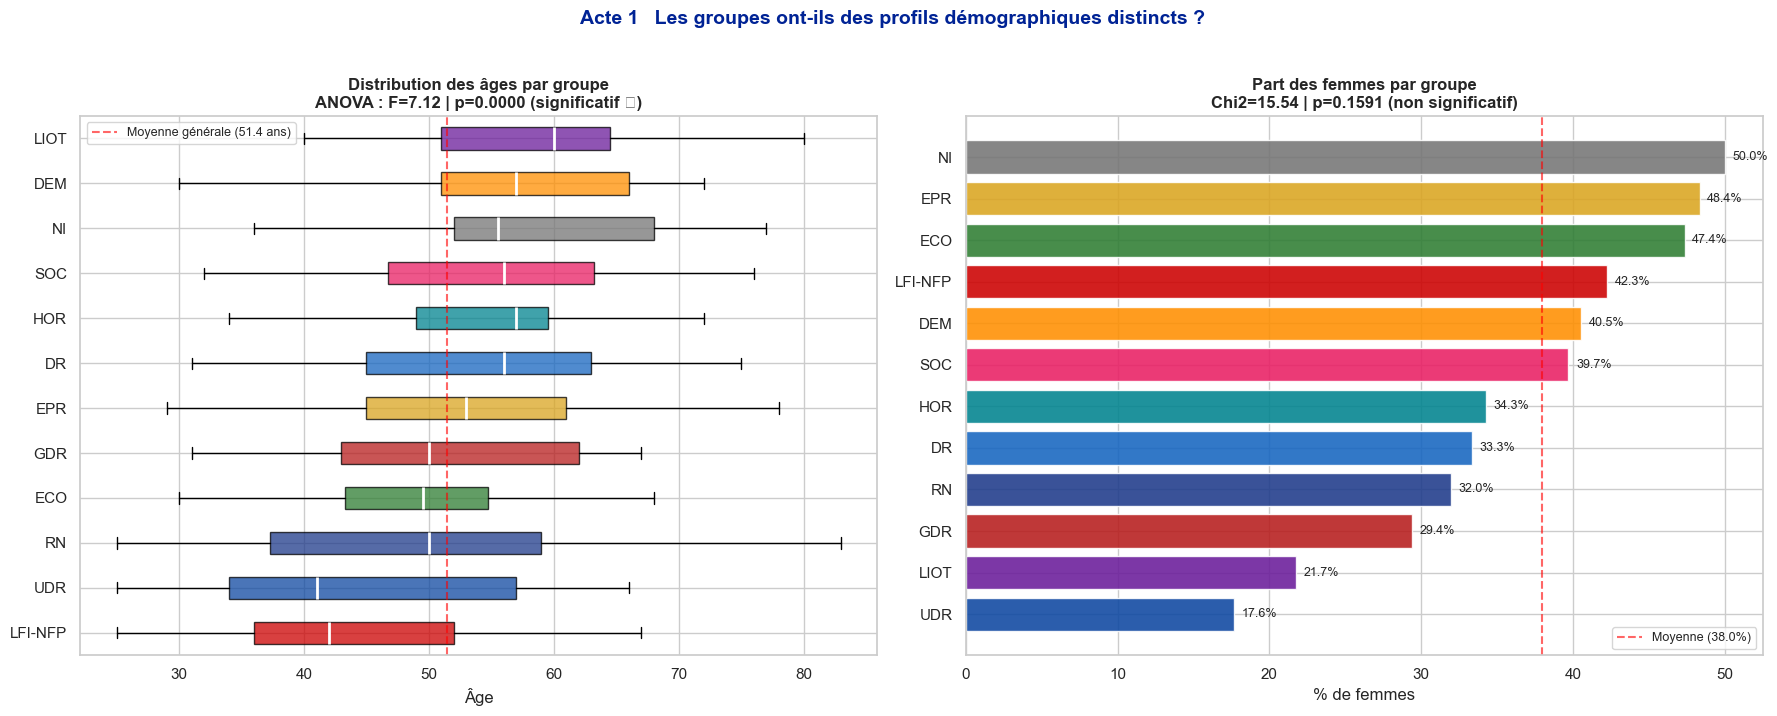

✅ Figure 4 sauvegardée

── TESTS STATISTIQUES ──────────────────────────────
   ANOVA âge entre groupes   : F=7.120 | p=0.0000
   → Différences significatives entre groupes ✓

   Chi2 parité entre groupes : χ²=15.539 | p=0.1591 | ddl=11
   → Pas de différence significative


In [10]:
from scipy.stats import f_oneway, chi2_contingency

age_par_groupe = (
    df.groupby("groupe_sigle")["age"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
    .sort_values("mean")
)
femmes_par_groupe = (
    df.groupby("groupe_sigle")
    .apply(lambda x: (x["genre"] == "Femme").mean() * 100)
    .reset_index(name="pct_femmes")
)
stats_groupe = age_par_groupe.merge(femmes_par_groupe, on="groupe_sigle")
stats_groupe["couleur"] = stats_groupe["groupe_sigle"].map(COULEURS_GROUPES)

groupes_ages = [
    df[df["groupe_sigle"] == g]["age"].dropna().values
    for g in df["groupe_sigle"].unique()
]
f_stat, p_anova = f_oneway(*groupes_ages)

contingency = pd.crosstab(df["groupe_sigle"], df["genre"])
chi2_stat, p_chi2, dof, expected = chi2_contingency(contingency)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bp_data = [
    df[df["groupe_sigle"] == g]["age"].dropna().values
    for g in stats_groupe["groupe_sigle"]
]
bp = axes[0].boxplot(
    bp_data,
    patch_artist=True,
    vert=False,
    medianprops=dict(color="white", linewidth=2)
)
for patch, color in zip(bp["boxes"], stats_groupe["couleur"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_yticklabels(stats_groupe["groupe_sigle"])
axes[0].axvline(df["age"].mean(), color="red", linestyle="--",
                alpha=0.6, label=f"Moyenne générale ({df['age'].mean():.1f} ans)")
axes[0].set_xlabel("Âge")
axes[0].set_title(
    f"Distribution des âges par groupe\n"
    f"ANOVA : F={f_stat:.2f} | p={p_anova:.4f} "
    f"({'significatif ✓' if p_anova < 0.05 else 'non significatif'})",
    fontsize=12, fontweight="bold"
)
axes[0].legend(fontsize=9)

femmes_sort = stats_groupe.sort_values("pct_femmes")
bars = axes[1].barh(
    femmes_sort["groupe_sigle"],
    femmes_sort["pct_femmes"],
    color=femmes_sort["couleur"],
    edgecolor="white", alpha=0.88
)
axes[1].axvline(
    (df["genre"] == "Femme").mean() * 100,
    color="red", linestyle="--", alpha=0.6,
    label=f"Moyenne ({(df['genre']=='Femme').mean()*100:.1f}%)"
)
for bar, val in zip(bars, femmes_sort["pct_femmes"]):
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%", va="center", fontsize=9
    )
axes[1].set_xlabel("% de femmes")
axes[1].set_title(
    f"Part des femmes par groupe\n"
    f"Chi2={chi2_stat:.2f} | p={p_chi2:.4f} "
    f"({'significatif ✓' if p_chi2 < 0.05 else 'non significatif'})",
    fontsize=12, fontweight="bold"
)
axes[1].legend(fontsize=9)

plt.suptitle(
    "Acte 1   Les groupes ont-ils des profils démographiques distincts ?",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/04_demographie_par_groupe.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 sauvegardée")
print(f"\n── TESTS STATISTIQUES ──────────────────────────────")
print(f"   ANOVA âge entre groupes   : F={f_stat:.3f} | p={p_anova:.4f}")
print(f"   → {'Différences significatives entre groupes ✓' if p_anova < 0.05 else 'Pas de différence significative'}")
print(f"\n   Chi2 parité entre groupes : χ²={chi2_stat:.3f} | p={p_chi2:.4f} | ddl={dof}")
print(f"   → {'Différences significatives de parité entre groupes ✓' if p_chi2 < 0.05 else 'Pas de différence significative'}")

Résumé acte 1 

In [11]:
print("=" * 55)
print("ACTE 1   SYNTHÈSE : PORTRAIT DE L'HÉMICYCLE")
print("=" * 55)
print(f"""
🔍  QUALITÉ DES DONNÉES
   Enregistrements bruts en base    : {len(df_brut):,}
   Sans groupe politique (ignorés)  : {len(df_brut) - len(df):,}
   Députés actifs retenus           : {len(df):,}
   Taux de complétion global        : {df.notna().mean().mean()*100:.1f}%

🏛️  FRAGMENTATION (HHI = {HHI:.3f})
   {len(df_groupes)} groupes   nombre effectif : {N_eff:.1f}
   Groupe dominant : {groupes_count.iloc[0]['groupe_sigle']} 
   ({groupes_count.iloc[0]['pct']}% des sièges)
   Majorité absolue (289) : hors de portée

👥  DÉMOGRAPHIE
   Femmes : {(df['genre']=='Femme').sum()} ({(df['genre']=='Femme').mean()*100:.1f}%)
   Âge moyen : {ages.mean():.1f} ans (σ={ages.std():.1f})
   Skewness : {ages.skew():.2f}

📊  TESTS STATISTIQUES
   ANOVA âge     : p={p_anova:.4f} → {'significatif ✓' if p_anova < 0.05 else 'non significatif'}
   Chi2 parité   : p={p_chi2:.4f} → {'significatif ✓' if p_chi2 < 0.05 else 'non significatif'}

💾  EXPORTS
   data/processed/deputes_clean.csv
   data/processed/kpis_summary.csv
   data/processed/01_qualite_nettoyage.png
   data/processed/02_fragmentation_hemicycle.png
   data/processed/03_portrait_demographique.png
   data/processed/04_demographie_par_groupe.png
""")

ACTE 1   SYNTHÈSE : PORTRAIT DE L'HÉMICYCLE

🔍  QUALITÉ DES DONNÉES
   Enregistrements bruts en base    : 577
   Sans groupe politique (ignorés)  : 0
   Députés actifs retenus           : 577
   Taux de complétion global        : 99.7%

🏛️  FRAGMENTATION (HHI = 0.121)
   12 groupes   nombre effectif : 8.3
   Groupe dominant : RN 
   (21.1% des sièges)
   Majorité absolue (289) : hors de portée

👥  DÉMOGRAPHIE
   Femmes : 219 (38.0%)
   Âge moyen : 51.4 ans (σ=12.0)
   Skewness : -0.04

📊  TESTS STATISTIQUES
   ANOVA âge     : p=0.0000 → significatif ✓
   Chi2 parité   : p=0.1591 → non significatif

💾  EXPORTS
   data/processed/deputes_clean.csv
   data/processed/kpis_summary.csv
   data/processed/01_qualite_nettoyage.png
   data/processed/02_fragmentation_hemicycle.png
   data/processed/03_portrait_demographique.png
   data/processed/04_demographie_par_groupe.png

